# 02.1 — Vectors & Matrices

**Phase:** 02 — Mathematics for ML

**Status:** VERIFIED

---

## 1. What Are We Solving?

Machine learning is built on **linear algebra**. Data points are vectors, datasets are matrices, and model weights are matrices. Understanding vectors and matrices is essential for understanding how ML models work.

## 2. Why Does This Matter?

Every ML model — from linear regression to neural networks — is a series of vector/matrix operations. Understanding these operations lets you reason about what models do and why they work.

## 3. Prerequisites

- Unit 01.5 (NumPy)

## 4. Learning Objectives

By the end of this notebook, you should be able to:
- Understand what vectors and matrices are
- Represent them in NumPy
- Compute vector norms and dot products
- Understand matrix shapes and indexing
- Understand the geometric intuition of vectors

## 5. Mental Model

A **vector** is an arrow in space — it has a direction and a magnitude. A **matrix** is a grid of numbers that can transform vectors (rotate, scale, project). In ML, a row of data is a vector, and a dataset is a matrix.

## 6. Vectors

A **vector** is an ordered list of numbers. In ML, a vector often represents a single data point (e.g., `[age, salary, experience]`).

In [1]:
import numpy as np

# A vector is a 1D array
v = np.array([3, 4])
print(f"v: {v}")
print(f"v shape: {v.shape}")
print(f"v ndim: {v.ndim}")

# A data point as a vector
person = np.array([30, 75000, 5])  # age, salary, years experience
print(f"\nperson: {person}")
print(f"age: {person[0]}, salary: {person[1]}, experience: {person[2]}")

v: [3 4]
v shape: (2,)
v ndim: 1

person: [   30 75000     5]
age: 30, salary: 75000, experience: 5


## 7. Vector Magnitude (Norm)

The **magnitude** (or **norm**) of a vector is its length. For a 2D vector `(x, y)`, the magnitude is `sqrt(x² + y²)` — the Pythagorean theorem.

In [2]:
# Vector magnitude (L2 norm)
v = np.array([3, 4])

# Manual: sqrt(3^2 + 4^2) = sqrt(25) = 5
manual = np.sqrt(np.sum(v**2))
print(f"Manual magnitude: {manual}")

# Using np.linalg.norm
norm = np.linalg.norm(v)
print(f"np.linalg.norm: {norm}")

# L1 norm (sum of absolute values)
l1 = np.sum(np.abs(v))
print(f"L1 norm: {l1}")

Manual magnitude: 5.0
np.linalg.norm: 5.0
L1 norm: 7


## 8. Dot Product

The **dot product** of two vectors measures how aligned they are. It's the sum of element-wise products.

`a · b = a₁b₁ + a₂b₂ + ... + aₙbₙ`

The dot product is also `|a||b|cos(θ)`, where θ is the angle between them. If the dot product is 0, the vectors are **orthogonal** (perpendicular).

In [3]:
# Dot product
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])

# Manual
manual = sum(x * y for x, y in zip(a, b))
print(f"Manual dot product: {manual}")

# Using numpy
dot = np.dot(a, b)
print(f"np.dot: {dot}")

# Using @ operator
print(f"a @ b: {a @ b}")

# Orthogonal vectors have dot product 0
orth1 = np.array([1, 0])
orth2 = np.array([0, 1])
print(f"\nOrthogonal dot product: {np.dot(orth1, orth2)}")

Manual dot product: 32
np.dot: 32
a @ b: 32

Orthogonal dot product: 0


## 9. Matrices

A **matrix** is a 2D grid of numbers. In ML, a matrix often represents a dataset (rows = samples, columns = features) or model weights.

In [4]:
# Matrices
# A dataset: 3 samples, 2 features
X = np.array([
    [1, 2],   # sample 1
    [3, 4],   # sample 2
    [5, 6],   # sample 3
])

print(f"X:\n{X}")
print(f"shape: {X.shape}")
print(f"ndim: {X.ndim}")
print(f"\nX[0]: {X[0]}")       # first sample (row)
print(f"X[:, 0]: {X[:, 0]}")   # first feature (column)
print(f"X[1, 1]: {X[1, 1]}")   # row 1, col 1

X:
[[1 2]
 [3 4]
 [5 6]]
shape: (3, 2)
ndim: 2

X[0]: [1 2]
X[:, 0]: [1 3 5]
X[1, 1]: 4


## 10. Matrix Transpose

The **transpose** flips a matrix over its diagonal: rows become columns and vice versa.

In [5]:
# Transpose
A = np.array([[1, 2, 3], [4, 5, 6]])
print(f"A (2x3):\n{A}")
print(f"A.T (3x2):\n{A.T}")
print(f"A shape: {A.shape}, A.T shape: {A.T.shape}")

A (2x3):
[[1 2 3]
 [4 5 6]]
A.T (3x2):
[[1 4]
 [2 5]
 [3 6]]
A shape: (2, 3), A.T shape: (3, 2)


## 11. Identity and Diagonal Matrices

The **identity matrix** has 1s on the diagonal and 0s elsewhere. Multiplying by it leaves a matrix unchanged (like multiplying by 1).

In [6]:
# Identity matrix
I = np.eye(3)
print(f"Identity (3x3):\n{I}")

# Diagonal matrix
D = np.diag([1, 2, 3])
print(f"\nDiagonal:\n{D}")

# Identity leaves a matrix unchanged
A = np.array([[1, 2], [3, 4]])
print(f"\nA @ I2:\n{A @ np.eye(2)}")
print(f"Same as A: {np.allclose(A @ np.eye(2), A)}")

Identity (3x3):
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

Diagonal:
[[1 0 0]
 [0 2 0]
 [0 0 3]]

A @ I2:
[[1. 2.]
 [3. 4.]]
Same as A: True


## 12. Geometric Intuition

A vector is an arrow. Let's visualize vectors and their operations.

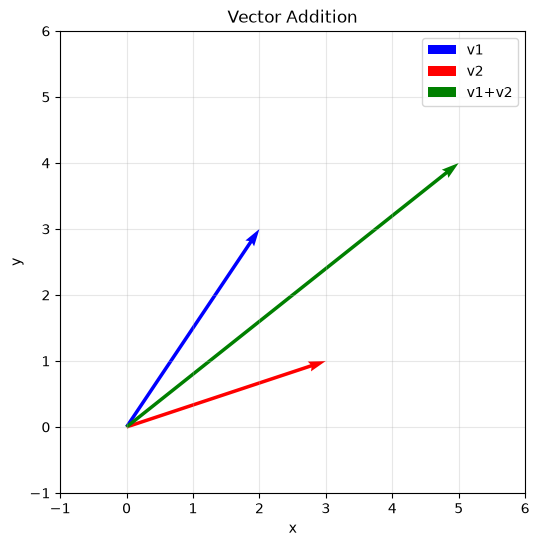

In [7]:
import matplotlib.pyplot as plt

# Visualize vectors
v1 = np.array([2, 3])
v2 = np.array([3, 1])

fig, ax = plt.subplots(figsize=(6, 6))

# Draw vectors as arrows from origin
ax.quiver(0, 0, v1[0], v1[1], angles="xy", scale_units="xy", scale=1, color="blue", label="v1")
ax.quiver(0, 0, v2[0], v2[1], angles="xy", scale_units="xy", scale=1, color="red", label="v2")

# Vector sum
vsum = v1 + v2
ax.quiver(0, 0, vsum[0], vsum[1], angles="xy", scale_units="xy", scale=1, color="green", label="v1+v2")

ax.set_xlim(-1, 6)
ax.set_ylim(-1, 6)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Vector Addition")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

## 13. Experiment: Cosine Similarity

**Cosine similarity** measures how similar two vectors are (used in NLP for word/document similarity). It's the cosine of the angle between them.

`cos(θ) = (a · b) / (|a| |b|)`

In [8]:
# Cosine similarity
def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

# Similar vectors -> similarity close to 1
a = np.array([1, 2, 3])
b = np.array([2, 4, 6])  # 2*a, same direction
print(f"Similar vectors: {cosine_similarity(a, b):.3f}")

# Orthogonal vectors -> similarity 0
c = np.array([1, 0, 0])
d = np.array([0, 1, 0])
print(f"Orthogonal vectors: {cosine_similarity(c, d):.3f}")

# Opposite vectors -> similarity -1
e = np.array([1, 2, 3])
f = np.array([-1, -2, -3])
print(f"Opposite vectors: {cosine_similarity(e, f):.3f}")

Similar vectors: 1.000
Orthogonal vectors: 0.000
Opposite vectors: -1.000


## 14. Failure Case: Shape Confusion

A common error is confusing row vectors and column vectors, or using the wrong shape.

In [9]:
# Row vs column vector
row = np.array([1, 2, 3])        # shape (3,)
col = np.array([[1], [2], [3]])  # shape (3, 1)

print(f"row shape: {row.shape}")
print(f"col shape: {col.shape}")

# These are different! row @ row.T gives a scalar, col.T @ col gives a matrix
print(f"\nrow @ row: {row @ row}")  # scalar (dot product)
print(f"col @ col.T:\n{col @ col.T}")  # outer product (matrix)

row shape: (3,)
col shape: (3, 1)

row @ row: 14
col @ col.T:
[[1 2 3]
 [2 4 6]
 [3 6 9]]


## 15. Debugging: Common Errors

### Shape mismatch
```python
np.array([1,2,3]) @ np.array([[1,2],[3,4]])  # ValueError
```

### Confusing row/column vectors
`(3,)` vs `(3,1)` are different shapes.

### Using `*` instead of `@`
`*` is element-wise; `@` is matrix multiplication.

## 16. Real-World Considerations

- **Data as matrix**: rows = samples, columns = features.
- **Weights as matrix**: neural network layers are weight matrices.
- **Normalization**: normalize vectors (unit vectors) for similarity.
- **dtype**: use `float32`/`float64` appropriately.

## 17. Common Mistakes

- Confusing `*` and `@`
- Shape mismatches
- Forgetting that `(n,)` and `(n,1)` differ
- Not normalizing vectors for similarity

## 18. When NOT to Use

- Don't use manual loops for vector ops — use NumPy.
- Don't use NumPy for deep learning tensors — use PyTorch.

## 19. Challenge

Given two vectors, compute the angle between them in degrees using the dot product formula.

In [10]:
# Challenge: angle between vectors
a = np.array([1, 0])
b = np.array([0, 1])

cos_theta = np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))
angle_rad = np.arccos(np.clip(cos_theta, -1, 1))
angle_deg = np.degrees(angle_rad)

print(f"cos(theta): {cos_theta:.3f}")
print(f"angle: {angle_deg:.1f} degrees")

# Another pair
c = np.array([1, 1])
d = np.array([1, 0])
cos2 = np.dot(c, d) / (np.linalg.norm(c) * np.linalg.norm(d))
print(f"\nAngle between (1,1) and (1,0): {np.degrees(np.arccos(np.clip(cos2, -1, 1))):.1f} degrees")

cos(theta): 0.000
angle: 90.0 degrees

Angle between (1,1) and (1,0): 45.0 degrees


## 20. Closed-Book Recall

Without looking back:

1. What is a vector? A matrix?
2. How do you compute the magnitude of a vector?
3. What does the dot product measure?
4. What is the transpose?
5. What is cosine similarity?

## 21. Teach-Back Questions

Explain to another person:

- How is a dataset represented as a matrix?
- What does the dot product tell you about two vectors?
- Why is cosine similarity useful?

## 22. Summary

You now understand vectors, matrices, norms, dot products, and cosine similarity. These are the building blocks of linear algebra used throughout ML.

## 23. Further Experiment

- Compute the outer product of two vectors.
- Visualize vector scaling (multiplying by a scalar).
- Compute cosine similarity between word embeddings (later in NLP).

## 24. Verification Status

```
STATUS: VERIFIED
EXECUTION: PASS
DEPENDENCIES: numpy, matplotlib
OUTPUTS: PASS
LAST VERIFIED: 2026-08-28
```